# Lab 2: Assestment of aircraft engine vanes quality using textural features

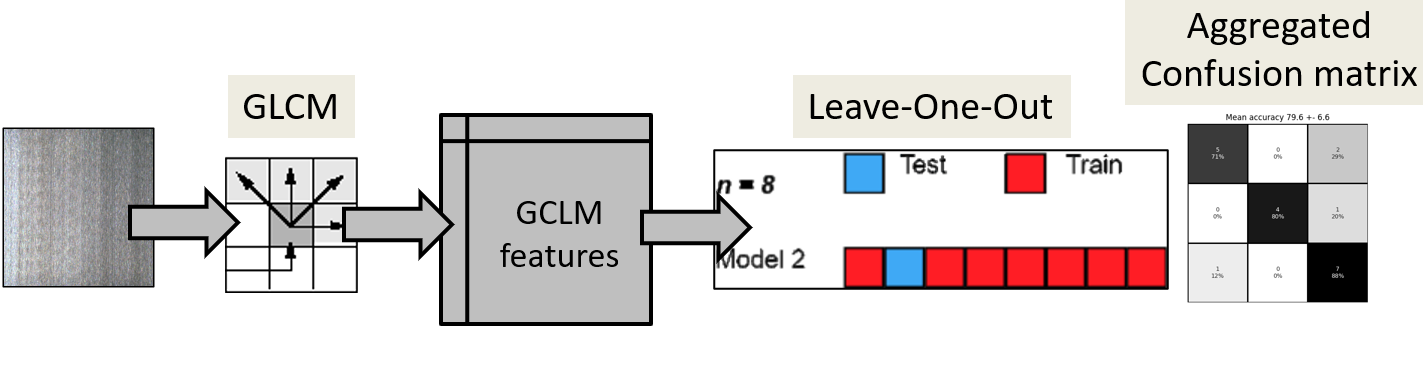

## Import and settings

In [2]:
import os
import glob
import skimage
import numpy as np
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

In [3]:
!git clone https://github.com/frpnz/teaching-Roughness.git
ROOTDIR_DATASET = "/content/teaching-Roughness/data"

Cloning into 'teaching-Roughness'...
remote: Enumerating objects: 25, done.
remote: Total 25 (delta 0), reused 0 (delta 0), pack-reused 25 (from 1)
Receiving objects: 100% (25/25), 87.46 MiB | 35.27 MiB/s, done.


## Functions

In [4]:
def seaborn_cm(cm, ax, tick_labels, fontsize=14, title=None, sum_actual="over_columns",
               xrotation=0, yrotation=0):
    """
    Function to plot a confusion matrix
    """
    from matplotlib import cm as plt_cmap
    group_counts = ["{:0.0f}".format(value) for value in cm.flatten()]
    if sum_actual == "over_columns":
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    elif sum_actual == "over_rows":
        cm = cm.astype('float') / cm.sum(axis=0)[:, np.newaxis]
    else:
        print("sum_actual must be over_columns or over_rows")
        exit()
    cm = np.nan_to_num(cm)
    mean_acc = np.mean(np.diag(cm)[cm.sum(axis=1) != 0])
    std_acc = np.std(np.diag(cm))
    group_percentages = ["{:0.0f}".format(value*100) for value in cm.flatten()]
    cm_labels = [f"{c}\n{p}%" for c, p in zip(group_counts, group_percentages)]
    cm_labels = np.asarray(cm_labels).reshape(len(tick_labels), len(tick_labels))
    sns.heatmap(cm,
                ax=ax,
                annot=cm_labels,
                fmt='',
                cbar=False,
                cmap=plt_cmap.Greys,
                linewidths=1, linecolor='black',
                annot_kws={"fontsize": fontsize},
                xticklabels=tick_labels,
                yticklabels=tick_labels)
    ax.set_yticklabels(ax.get_yticklabels(), size=fontsize, rotation=yrotation)
    ax.set_xticklabels(ax.get_xticklabels(), size=fontsize, rotation=xrotation)
    if title:
        title = f"{title}\nMean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    else:
        title = f"Mean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    ax.set_title(title)
    if sum_actual == "over_columns":
        ax.set_ylabel("Actual")
        ax.set_xlabel("Predicted")
    else:
        ax.set_ylabel("Predicted")
        ax.set_xlabel("Actual")

def my_imshow(image, title=None):
    fig, ax = plt.subplots(1, 1)
    if len(image.shape) > 2:
        ax.imshow(image)
    else:
        ax.imshow(image, cmap=plt.cm.gray)
    ax.axis("off")
    if title:
        ax.set_title(title)

#Assignment #1: Get all filepaths ending with `".bmp"`

In [5]:
import os
from pathlib import Path

filepaths = [os.path.join(ROOTDIR_DATASET, f) for f in os.listdir(ROOTDIR_DATASET) if f.endswith(".bmp")]
print(filepaths)

['/content/teaching-Roughness/data/OK-B_5-2.013.bmp', '/content/teaching-Roughness/data/NOK-A_27_10-5.876.bmp', '/content/teaching-Roughness/data/OK-A_28-1.576.bmp', '/content/teaching-Roughness/data/NOK-A_27_10-6.807.bmp', '/content/teaching-Roughness/data/NOK-B_2-6.940.bmp', '/content/teaching-Roughness/data/DOUBT-A_27_10-5.474.bmp', '/content/teaching-Roughness/data/DOUBT-A_12-4.387.bmp', '/content/teaching-Roughness/data/OK-A_34-3.424.bmp', '/content/teaching-Roughness/data/OK-A_34-3.461.bmp', '/content/teaching-Roughness/data/DOUBT-B_2-4.758.bmp', '/content/teaching-Roughness/data/DOUBT-A_34-4.715.bmp', '/content/teaching-Roughness/data/DOUBT-A_12-4.469.bmp', '/content/teaching-Roughness/data/NOK-B_2-5.806.bmp', '/content/teaching-Roughness/data/OK-A_28-3.047.bmp', '/content/teaching-Roughness/data/DOUBT-B_5-4.455.bmp', '/content/teaching-Roughness/data/OK-A_12-3.206.bmp', '/content/teaching-Roughness/data/OK-A_12-3.757.bmp', '/content/teaching-Roughness/data/DOUBT-A_34-4.299.bmp'

#Assignment #2: Plot some images from training set.

Create a single figure object with several subplots and remove axis where not needed.
Set the filename as title for the single subplot.

There exixt several packages to manipulate images in Python. Consider the following three, that are very popular:


*   [skimage](https://scikit-image.org/)
*   [Image module](https://pillow.readthedocs.io/en/stable/reference/Image.html) of Pillow
*   [OpenCV](https://pypi.org/project/opencv-python/)


In [6]:
from skimage.io import imread
from skimage.exposure import rescale_intensity

imgs = [
    rescale_intensity(
        imread(f, as_gray=True),
        in_range='image',
        out_range="uint8"
    ) for f in filepaths
  ]


In [7]:
imgs[0]

array([[150, 155, 155, ...,  18,  15,  19],
       [161, 164, 163, ...,  16,  17,  21],
       [171, 178, 175, ...,  19,  22,  25],
       ...,
       [130, 103, 113, ..., 111,  90,  68],
       [140, 106, 115, ..., 103,  82,  75],
       [180, 108, 127, ..., 106,  81,  77]], dtype=uint8)

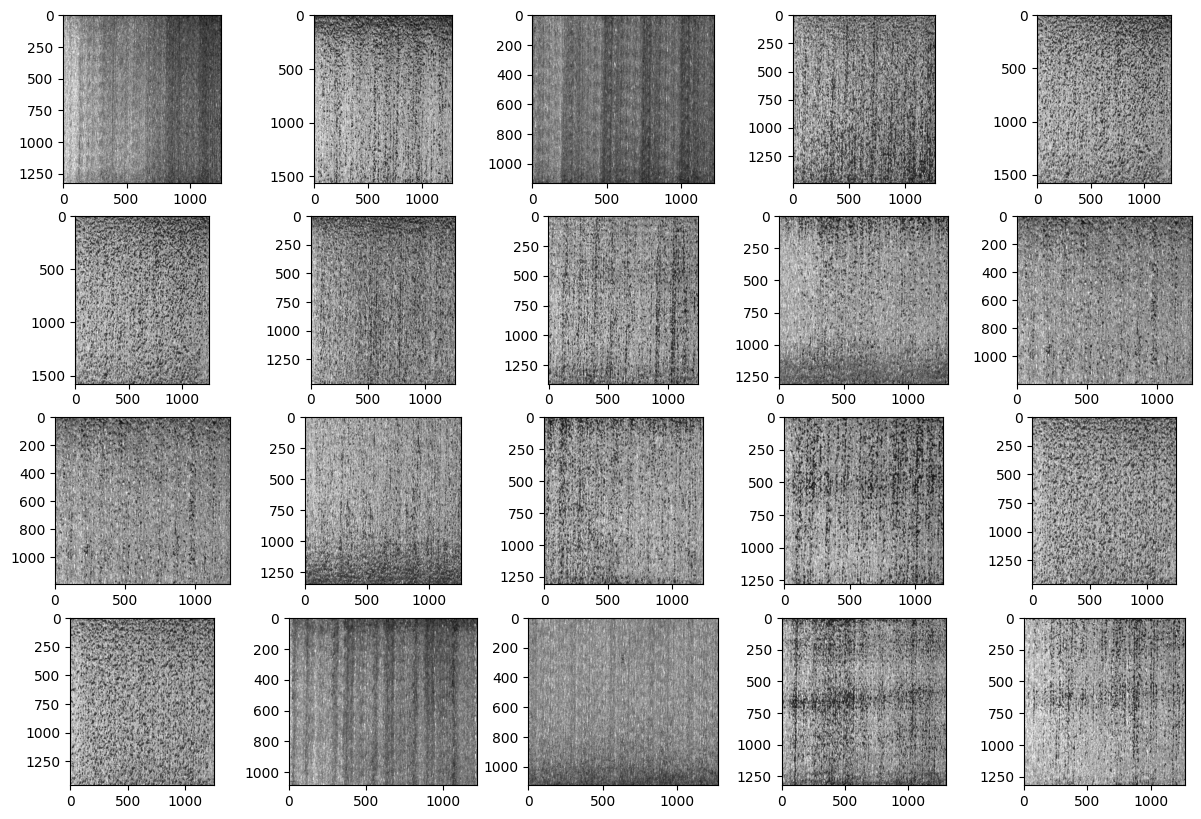

In [8]:
fig, ax = plt.subplots(4, 5, figsize=(15, 10))

for m in range(0, 4):
  for n in range(0,5):
    ax[m][n].imshow(imgs[m*4+n], cmap='gray', vmin=0, vmax=255)

fig.show()

# Assignment #3: extract the so-called Gray-Level Co-Occurrence matrix (GLCM)

The GLCM is computed by calculating how often a pixel with the intensity (gray-level) value i occurs in a specific spatial relationship to a pixel with the value j.

To illustrate, the following figure shows how graycomatrix calculates the first three values in a GLCM. In the output GLCM, element (1, 1) contains the value 1 because there is only one instance in the input image where two horizontally adjacent pixels have the values 1 and 1, respectively. Element (1, 2) contains the value 2 because there are two instances where two horizontally adjacent pixels have the values 1 and 2. Element (1, 3) has the value 0 because there are no instances of two horizontally adjacent pixels with the values 1 and 3. graycomatrix continues processing the input image, scanning the image for other pixel pairs (i, j) and recording the sums in the corresponding elements of the GLCM.

source: https://it.mathworks.com/help/images/create-a-gray-level-co-occurrence-matrix.html

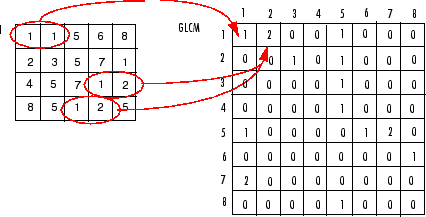

# Code the pipeline to extract the GLC from a single image.


Steps:

1. Some preprocssing operations are required. See the documentation of [skimage.feature.graycomatrix](https://scikit-image.org/docs/stable/api/skimage.feature.html#graycomatrix), paying particular **attention to the required input format**.
1. Exploit the function [skimage.feature.graycomatrix](https://scikit-image.org/docs/stable/api/skimage.feature.html#graycomatrix) to compute the GLCM. For now, set a single value for the `distances` and `angles` parameters.
2. Compute all the available texture properties of the GLCM, through [graycoprops](https://scikit-image.org/docs/stable/api/skimage.feature.html#graycoprops) function.
4. Go back to step 2 and try different values for the `distances` and `angles` parameters. How this affect the shape of the value returned by the *skimage.feature.graycomatrix* function?

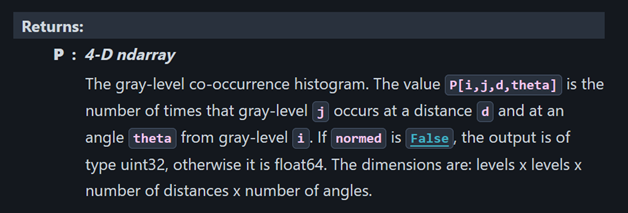

In [9]:
from skimage.feature import graycomatrix, graycoprops

distances = [1]
angles = [n*np.pi/4 for n in range(0,8)] # circle in steps of pi/4

glcs = list()
prop_names = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM", "mean", "variance", "std", "entropy"]

for im in imgs:
  glcm = graycomatrix(im, distances, angles)
  props = [graycoprops(glcm, prop=p_name) for p_name in prop_names]
  glcs.append(props)

glcs = np.array(glcs).reshape(len(imgs),-1)

In [10]:
class GLCMProps:
  def __init__(self, images, neighboor_distance, neighboor_directions: str) -> None:
      self._imgs = images

      self.distances = [neighboor_distance]

      if neighboor_directions == "sides":
        self.angles = [n*np.pi/4 for n in range(0,8)]
      elif neighboor_directions == "diagonals":
        self.angles = [n*np.pi/4 for n in range(0,8)]
      elif neighboor_directions == "all":
        self.angles = [n*np.pi/4 for n in range(0,8)]

      self.prop_names = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM", "mean", "variance", "std", "entropy"]

  def get_props(self):
    glcs = list()
    for im in self._imgs:
      glcm = graycomatrix(im, distances, angles)
      props = [graycoprops(glcm, prop=p_name) for p_name in prop_names]
      glcs.append(props)
    glcs = np.array(glcs).reshape(len(self._imgs),-1)

    attribute_names = list()
    for angle in self.angles:
      for p_name in prop_names:
        attribute_names.append(f"{p_name}_angle{angle}")

    return glcs, attribute_names


In [11]:
props, attributes = GLCMProps(imgs, 1, "sides").get_props()
print(attributes)
print(props.shape)

['contrast_angle0.0', 'dissimilarity_angle0.0', 'homogeneity_angle0.0', 'energy_angle0.0', 'correlation_angle0.0', 'ASM_angle0.0', 'mean_angle0.0', 'variance_angle0.0', 'std_angle0.0', 'entropy_angle0.0', 'contrast_angle0.7853981633974483', 'dissimilarity_angle0.7853981633974483', 'homogeneity_angle0.7853981633974483', 'energy_angle0.7853981633974483', 'correlation_angle0.7853981633974483', 'ASM_angle0.7853981633974483', 'mean_angle0.7853981633974483', 'variance_angle0.7853981633974483', 'std_angle0.7853981633974483', 'entropy_angle0.7853981633974483', 'contrast_angle1.5707963267948966', 'dissimilarity_angle1.5707963267948966', 'homogeneity_angle1.5707963267948966', 'energy_angle1.5707963267948966', 'correlation_angle1.5707963267948966', 'ASM_angle1.5707963267948966', 'mean_angle1.5707963267948966', 'variance_angle1.5707963267948966', 'std_angle1.5707963267948966', 'entropy_angle1.5707963267948966', 'contrast_angle2.356194490192345', 'dissimilarity_angle2.356194490192345', 'homogeneity

#Assignment #4: Create the dataset (X, y) by:

1.   Extracting the GLCM from all images.
2.   Extracting the main properties from the GLCM matrix, six features in total (see [graycoprops](https://scikit-image.org/docs/stable/api/skimage.feature.html#graycoprops)). Employ different values for the  `distances` and `angles` parameters of [skimage.feature.graycomatrix](https://scikit-image.org/docs/stable/api/skimage.feature.html#graycomatrix).
3.   Extract the corresponding numerical label from the filename.




In [30]:
X_glcm, X_glcm_props = GLCMProps(imgs, 1, "sides").get_props()

label_mapping = {"OK": 0, "NOK": 1, "DOUBT": 2}
y = np.array([
    label_mapping[
        fp.split("/")[-1]\
        .split("-")[0]
    ]
    for fp in filepaths
])

##Assignment #4.1: Reshape the dataset to be fed to sklearn, i.e. a `n_samples by m_features` matrix.
Note that the number of features depends on distances and angles parameters of skimage.feature.graycomatrix

In [13]:
# already done inside props class

#Assignment #5: Build and optimize the ML pipeline in a Leave-One-Out (LOO) cross-validation fashion and evaluate leveragin a confusion matrix
1.   Scale the data
2.   Implement PCA
3.   Optimize the hyperparameters of a classifier (e.g., SVM) and train it

> Note that in this case study we have really few samples. For this reason, we opted to built a LOO setting in which we use multiple training set, while at each iteration one single sample is consdiered as the test set. In this way, **we are evaluating a learning method**, not just an individual learned model.





In [19]:
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import reciprocal



In [20]:
SEED = 42

In [37]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(svd_solver='full')),
    ('svc', SVC())
])

In [52]:
param_distributions = {
    'svc__C': reciprocal(1, 1000),
    'svc__gamma': reciprocal(0.001, 1),
    'svc__kernel': ['rbf', 'linear'],
    'pca__n_components': [0.95, 0.99, 0.999]
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    random_state = SEED,
    n_iter = 50,
    n_jobs = -1,
    cv = 5
)

In [ ]:
label_mapping = {"OK": 0, "NOK": 1, "DOUBT": 2}
cm_aggregated = np.zeros((3, 3))

loo = LeaveOneOut()
for i, (train_index, test_index) in enumerate(loo.split(X_glcm)):
    search.fit(X_glcm[train_index], y[train_index])
    pred = search.predict(X_glcm[test_index])
    cm = confusion_matrix(y[test_index], pred, labels=np.unique(y))
    cm_aggregated += cm

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


## Confusion matrix

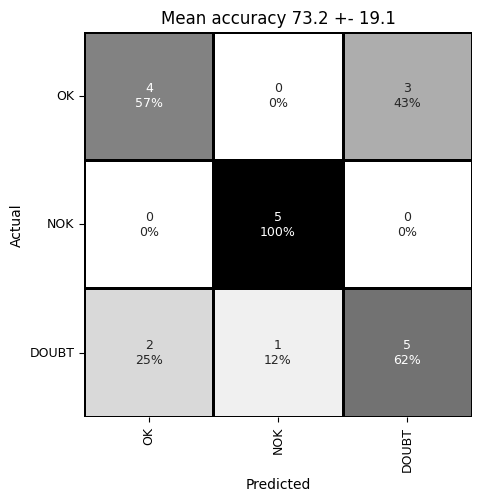

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
seaborn_cm(cm_aggregated, ax, list(label_mapping.keys()), fontsize=9, xrotation=90)